In [1]:
# # Run this and then restart the kernel at the start of each session to install
# # 'teotil3' in development mode
# !pip install -e /home/jovyan/projects/teotil3/

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import seaborn as sb
import teotil3 as teo

plt.style.use("ggplot")

In [3]:
eng = nivapy.da.connect_postgis()

Connection successful.


In [4]:
# Get REGINES
reg_gdf = teo.io.get_regine_geodataframe(eng, 2023)

# TEOTIL3 for Lillestrøm kommune
# Notebook 05: Inputs from wastewater overflows and "spredt"

Lillestrøm kommune has provided detailed data describing wastewater overflows and spredt. This notebook estimates nutrient inputs based on these datasets and compares results to the more general data from SSB used by "standard" runs of TEOTIL3.

## 1. Discharges per person per day

In [5]:
# Get a dict mapping parameters to per-person discharges
url = r"https://raw.githubusercontent.com/NIVANorge/teotil3/refs/heads/main/data/nutrient_discharges_per_person.csv"
pers_df = pd.read_csv(url)
pers_df

,parameter,g_per_pers_per_day
0,totn,12.0
1,totp,1.8
2,bof5,60.0
3,kof,120.0
4,ss,70.0


## 2. Overflows

The overflow dataset from Lillestrøm kommune is divided into two parts: rainwater overflows and emergency overflows. For each overflow, I have:

 * Outlet co-ordinates
 * Capacity (i.e. number of person-equivalents, p.e., when in operation)
 * Number of hours of operation each year from 2020 to 2025

Using this information and the table of per-person discharges above, we can estimate the annual nutrient discharge at each location as:

$$ D = \frac{C \times P \times H}{24 \times 1000}$$

where $D$ is the nutrient discharge in kg; $C$ is the overflow capacity in p.e.; $P$ is the nutrient discharge per person per day in g (from the table above); and $H$ is the number of hours of operation per year.

This equation can be used to estimate annual overflows of TOTN, TOTP, BOF5, KOF and SS. To estimate fractions of N and P and TOC, we use the factors for `Urenset` wastewater from the TEOTIL3 database. See table below.

In [6]:
# Read data to separate N and P fracs and estimate TOC
frac_url = r"https://raw.githubusercontent.com/NIVANorge/teotil3/refs/heads/main/data/point_source_treatment_types.csv"
frac_df = (
    pd.read_csv(frac_url)
    .query("(sector == 'Large wastewater') and (type == 'Urenset')")
    .rename(columns={"type": "teotil3_type"})
)
assert len(frac_df) == 1
frac_df

,sector,teotil3_type,prop_din,prop_ton,prop_tpp,prop_tdp,kof_fac,bof_fac
0,Large wastewater,Urenset,0.65,0.35,0.67,0.33,0.23,0.6


The code below reads the overflow data from Lillestrøm and estimates annual overflows of N, P, SS and TOC for each location. Each overflow is also assigned to a regine unit for further modelling using TEOTIL.

In [7]:
# Read overflow data
ov_xl_path = r"../data/lillestrom_wastewater_data.xlsx"
ov_df = pd.read_excel(ov_xl_path, sheet_name="overflows")

# Convert to long
id_cols = [col for col in ov_df.columns if not col.startswith("Hours_")]
ov_df = ov_df.melt(id_vars=id_cols, var_name="year", value_name="hours")
ov_df["year"] = ov_df["year"].str[-4:].astype(int)

# Estimate nutrients
for idx, row in pers_df.iterrows():
    par = row["parameter"]
    g_pers_day = row["g_per_pers_per_day"]
    ov_df[f"{par.upper()}_kg"] = (
        ov_df["capacity_pe"] * g_pers_day * ov_df["hours"] / (24 * 1000)
    )

# Convert KOF to TOC and estimate fractions of N and P
ov_df["TOC_kg"] = ov_df["KOF_kg"] * frac_df["kof_fac"].iloc[0]
ov_df["DIN_kg"] = ov_df["TOTN_kg"] * frac_df["prop_din"].iloc[0]
ov_df["TON_kg"] = ov_df["TOTN_kg"] * frac_df["prop_ton"].iloc[0]
ov_df["TDP_kg"] = ov_df["TOTP_kg"] * frac_df["prop_tdp"].iloc[0]
ov_df["TPP_kg"] = ov_df["TOTP_kg"] * frac_df["prop_tpp"].iloc[0]
ov_df = ov_df.drop(columns=["BOF5_kg", "KOF_kg"])

ov_df = ov_df.sort_values(["overflow_id", "year"])

# Convert UTM to lat/lon
ov_df["utm_zone"] = 32
ov_df = nivapy.spatial.utm_to_wgs84_dd(
    ov_df, zone="utm_zone", east="utm32_east", north="utm32_north"
).reset_index(drop=True)
ov_df["row_id"] = ov_df.index

# Assign to regines
ov_df = nivapy.spatial.identify_point_in_polygon(
    ov_df,
    reg_gdf,
    pt_col="row_id",
    poly_col="regine",
    lat_col="lat",
    lon_col="lon",
).dropna(subset="regine")

ov_df.head()

,parent_site,overflow_type,overflow_id,overflow_name,recipient,catchment,utm32_east,utm32_north,capacity_pe,year,...,TOC_kg,DIN_kg,TON_kg,TDP_kg,TPP_kg,utm_zone,lat,lon,row_id,regine
0,NRVA,Regnvannsoverløp,A2,A2 (OK16 - 66423) Jernbanegata,Nitelva,Nitelva,614321.11,6647652.82,8299.0,2020,...,5449.53835,1540.086925,829.277575,117.283543,238.121132,32,59.950379,11.046738,0,002.CB0
1,NRVA,Regnvannsoverløp,A2,A2 (OK16 - 66423) Jernbanegata,Nitelva,Nitelva,614321.11,6647652.82,8299.0,2021,...,849.40265,240.048575,129.256925,18.280622,37.115203,32,59.950379,11.046738,1,002.CB0
2,NRVA,Regnvannsoverløp,A2,A2 (OK16 - 66423) Jernbanegata,Nitelva,Nitelva,614321.11,6647652.82,8299.0,2022,...,906.66575,256.231625,137.970875,19.513024,39.617351,32,59.950379,11.046738,2,002.CB0
3,NRVA,Regnvannsoverløp,A2,A2 (OK16 - 66423) Jernbanegata,Nitelva,Nitelva,614321.11,6647652.82,8299.0,2023,...,76.35080,21.577400,11.618600,1.643202,3.336198,32,59.950379,11.046738,3,002.CB0
4,NRVA,Regnvannsoverløp,A2,A2 (OK16 - 66423) Jernbanegata,Nitelva,Nitelva,614321.11,6647652.82,8299.0,2024,...,4027.50470,1138.207850,612.881150,86.678906,175.984445,32,59.950379,11.046738,4,002.CB0


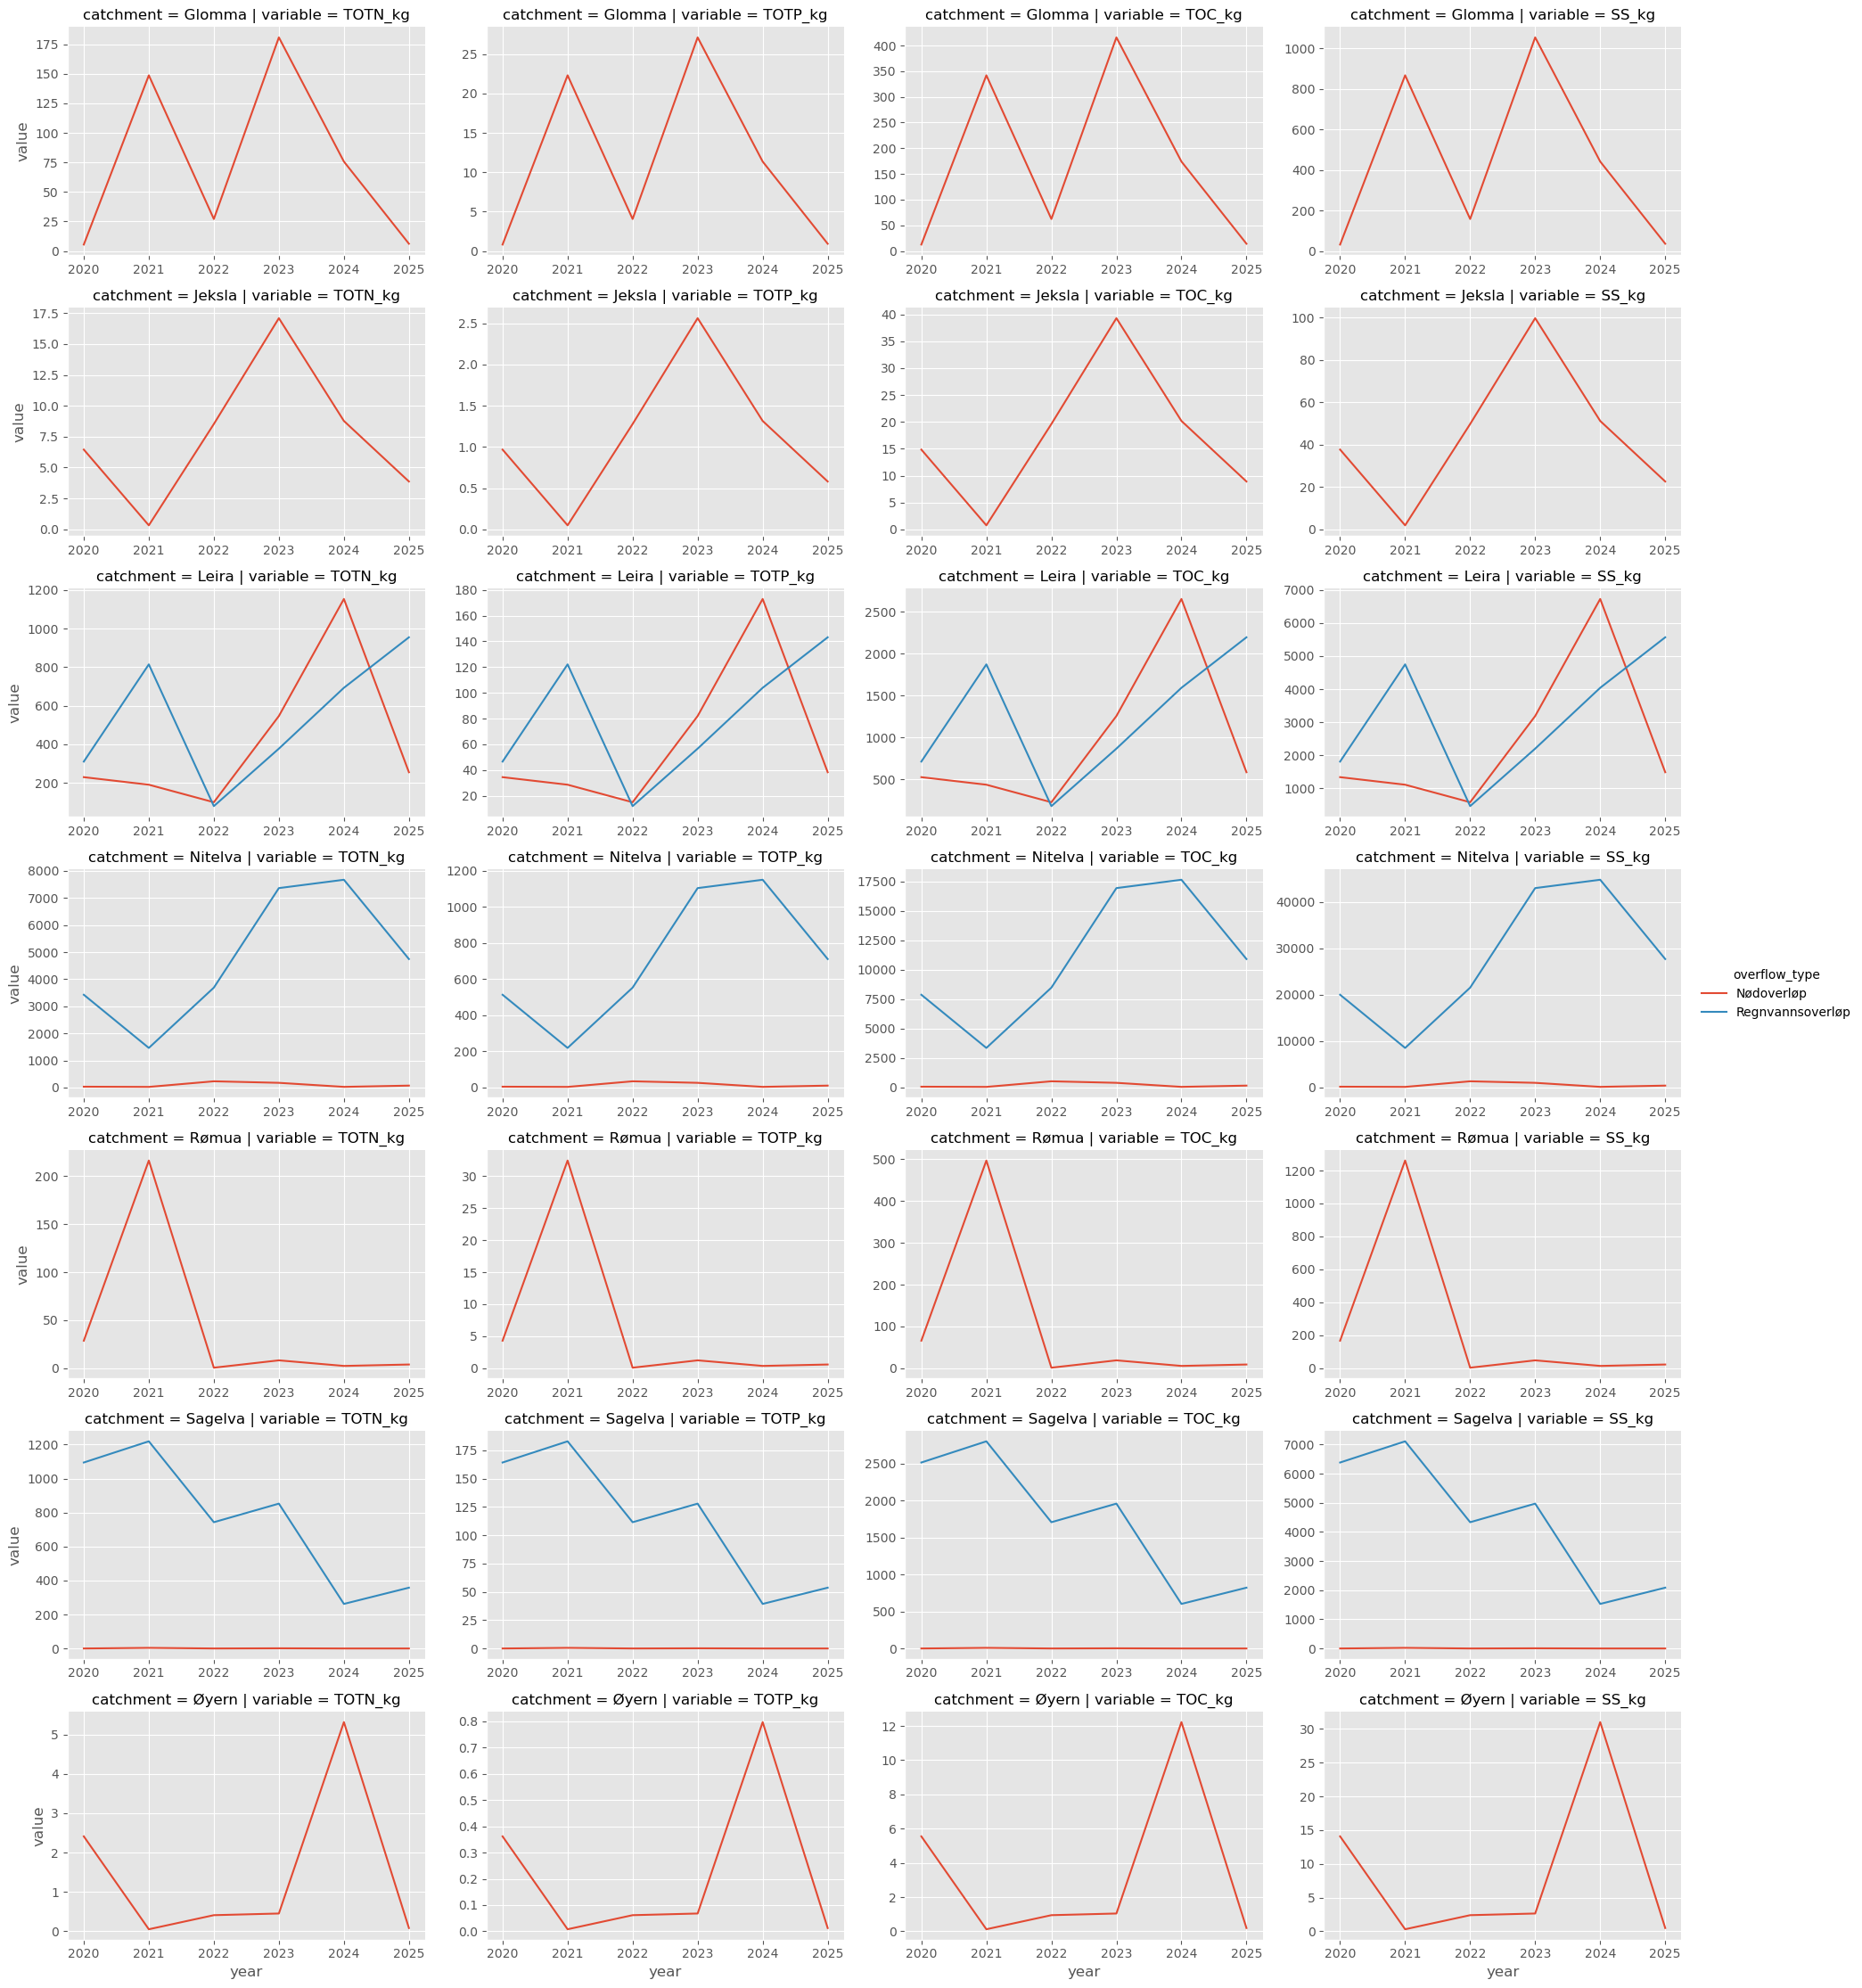

In [8]:
grp_cols = ["overflow_type", 'catchment', "year"]
val_cols = [
    "TOTN_kg",
    # "DIN_kg",
    # "TON_kg",
    "TOTP_kg",
    # "TDP_kg",
    # "TPP_kg",
    "TOC_kg",
    "SS_kg",
]
grp_ov_df = (
    ov_df[grp_cols + val_cols]
    .groupby(grp_cols)
    .sum(numeric_only=True)
    .reset_index()
    .melt(id_vars=grp_cols)
)

g = sb.relplot(
    data=grp_ov_df,
    x="year",
    y="value",
    row='catchment',
    col="variable",
    hue="overflow_type",
    # col_wrap=3,
    kind="line",
    facet_kws={"sharex": False, "sharey": False},
    height=3.2,
    aspect=1.5,
)

# # Fix y-limits
# ncols = 3
# for start in range(0, len(g.axes.flat), ncols):
#     row_axes = g.axes.flat[start : start + ncols]
#     ymin = min(ax.get_ylim()[0] for ax in row_axes)
#     ymax = max(ax.get_ylim()[1] for ax in row_axes)
#     for ax in row_axes:
#         ax.set_ylim(ymin, ymax)

The plots above show the total estimated overflows from each catchment for each TEOTIL parameter. Rainwater overflows are substantially larger than emergency overflows. Note also that all curves have the same shape, because they are all estimated based on "hours of operation per year".

For TEOTIL, I need data from 2013 onwards. Since Lillestrøm kommune cannot provide data before 2020, **I will use the median overflow value for each parameter for years from 2013 to 2019**. This is a coarse approximation, but is the best I can do given the available data.

In [9]:
# Aggregate to regine level
reg_ov_df = (
    ov_df[["regine", "year"] + val_cols]
    .groupby(["regine", "year"])
    .sum(numeric_only=True)
    .reset_index()
)

# Fill with median back to 2013
years = range(2013, 2026)

# Create complete regine-year index
full_index = pd.MultiIndex.from_product(
    [reg_ov_df["regine"].unique(), years], names=["regine", "year"]
)

# Median values per regine
regine_medians = reg_ov_df.groupby("regine")[val_cols].median()

# Reindex to get missing years
reg_ov_df = reg_ov_df.set_index(["regine", "year"]).reindex(full_index).reset_index()

# Fill missing values with regine medians
for col in val_cols:
    reg_ov_df[col] = reg_ov_df[col].fillna(reg_ov_df["regine"].map(regine_medians[col]))

# Save
csv_path = r"../data/lillestrom_regine_overflows.csv"
reg_ov_df.to_csv(csv_path, index=False)

reg_ov_df.head(15)

,regine,year,TOTN_kg,TOTP_kg,TOC_kg,SS_kg
0,002.C5,2013,0.14325,0.021488,0.329475,0.835625
1,002.C5,2014,0.14325,0.021488,0.329475,0.835625
2,002.C5,2015,0.14325,0.021488,0.329475,0.835625
3,002.C5,2016,0.14325,0.021488,0.329475,0.835625
4,002.C5,2017,0.14325,0.021488,0.329475,0.835625
5,002.C5,2018,0.14325,0.021488,0.329475,0.835625
6,002.C5,2019,0.14325,0.021488,0.329475,0.835625
7,002.C5,2020,2.41250,0.361875,5.548750,14.072917
8,002.C5,2021,0.05275,0.007913,0.121325,0.307708
9,002.C5,2022,0.00000,0.000000,0.000000,0.000000


## 3. Spredt

The spredt data from Lillestrøm includes the address and co-ordinates for each "small" (<50 p.e.) wastewater site within the kommune. The dataset includes the design capacity of each site, together with an estimate for the number of people actually using it (assumed to be half of the design capacity). See data sent by Jan Erik 12.08.2026.

The table below shows how site categories used by Lillestrøm kommune have been mapped to categories considered by TEOTIL3:

| Lillestrøm anleggstype | TEOTIL3 anleggstype |
|:----------------------:|:-------------------:|
| Annen løsning | Annen løsning |
| Avløpsfritt toalett | Biologisk toalett |
| Biofilter | Biologisk toalett, gråvannsfilter |
| Direkte utslipp | Direkte utslipp |
| Infiltrasjonsanlegg | Infiltrasjonsanlegg |
| Minirenseanlegg | Biologisk og kjemisk |
| Minirenseanlegg kl. 1 | Biologisk og kjemisk |
| Minirenseanlegg kl.1 | Biologisk og kjemisk |
| Minirenseanlegg kl.2 | Biologisk |
| Minirenseanlegg kl.3 | Kjemisk |
| Sandfilteranlegg | Sandfilteranlegg |
| Slamavskiller | Slamavskiller |
| Tett tank | Tett tank (for alt avløpsvann) |
| Tett tank med gråvannsfilter | Tett tank for svartvann, gråvannsfilter |
| tett tank og gråvanns SLM | Tett tank for svartvann, gråvannsfilter |

### 3.1. Estimate spredt inputs from Lillestrøm data

I will use the latest treatment efficiencies for spredt from NIBIO. This is consistent with other TEOTIL estimates for spredt, and also with the latest workflow from SSB.

In [10]:
# Read treatment efficiency data
url = r"https://raw.githubusercontent.com/NIVANorge/teotil3/refs/heads/main/data/treatment_efficiencies_small_wastewater.csv"
eff_df = pd.read_csv(url).set_index("teotil_type")
eff_df.head()

,ssb_code,ssb_desc,totn_eff_old_pct,totp_eff_old_pct,totn_eff_new_pct,totp_eff_new_pct,bof5_eff_new_pct,ss_eff_new_pct,totn_redfac_new_pct,totp_redfac_new_pct,bof5_redfac_new_pct,ss_redfac_new_pct
teotil_type,,,,,,,,,,,,
Direkte utslipp,FASTBOURENS2,Urenset utslipp,0,0,0,0,0,0,0,0,0,0
Slamavskiller,FASTBOSLAM2,Slamavskiller uten etterfiltrering,5,5,10,10,25,60,25,25,25,25
Infiltrasjonsanlegg,FASTBOINFILT2,Slamavskiller med infiltrasjon (stedegne masser),20,75,40,90,90,100,10,20,10,5
Sandfilteranlegg,FASTBOSAND2,Slamavskiller med sandfilter (tilførte masser),15,15,30,75,90,95,10,75,20,10
Biologisk,FASTBOBIO2,Minirenseanlegg - biologisk,10,15,30,60,90,80,10,20,10,20


To estimate fractions of N and P, and TOC, we use the `Small wastewater` factors from the TEOTIL3 database.

In [11]:
# Read data to separate N and P fracs and estimate TOC
frac_url = r"https://raw.githubusercontent.com/NIVANorge/teotil3/refs/heads/main/data/point_source_treatment_types.csv"
frac_df = (
    pd.read_csv(frac_url)
    .query("sector == 'Small wastewater'")
    .rename(columns={"type": "teotil3_type"})
)
frac_df

,sector,teotil3_type,prop_din,prop_ton,prop_tpp,prop_tdp,kof_fac,bof_fac
10,Small wastewater,Direkte utslipp,0.65,0.35,0.67,0.33,0.23,0.6
11,Small wastewater,Slamavskiller,0.68,0.32,0.35,0.65,0.23,0.6
12,Small wastewater,Infiltrasjonsanlegg,0.90,0.10,0.87,0.13,0.32,1.8
13,Small wastewater,Sandfilteranlegg,0.87,0.13,0.56,0.44,0.38,1.8
14,Small wastewater,Biologisk,0.87,0.13,0.56,0.44,0.38,1.8
15,Small wastewater,Kjemisk,0.72,0.28,0.87,0.13,0.33,0.9
16,Small wastewater,Biologisk og kjemisk,0.90,0.10,0.87,0.13,0.32,1.8
17,Small wastewater,Tett tank for svartvann,0.20,0.80,0.35,0.65,0.23,0.6
18,Small wastewater,Biologisk toalett,0.20,0.80,0.35,0.65,0.23,0.6
19,Small wastewater,Konstruert våtmark,0.90,0.10,0.66,0.34,0.32,1.8


The code below estimates annual discharges of nutrients from each site and assigns each location to a regine unit for modelling with TEOTIL.

Annual discharges are calculated as:

$$D = \frac{365.25 \times C \times P \times (1 - E)}{1000}$$

where $D$ is the nutrient discharge in kg; $C$ is the capacity in p.e.; $P$ is the nutrient discharge per person per day in g; and $E$ is the plant treatment efficiency (dimensionless value between 0 and 1).

The treatment efficiency, $E$, is calculated from data provided by NIBIO as:

$$E = E_{ideal} \times (1 - R)$$

where $E_{ideal}$ is the best-case efficiency of a new or well-maintained plant, and $R$ is a reduction factor representing how much the efficiency declines for a plant of typical age and condition.

In [12]:
# Read spredt data
sp_xl_path = r"../data/lillestrom_wastewater_data.xlsx"
sp_df = pd.read_excel(sp_xl_path, sheet_name="spredt")

# Assume 2.5 p.e. unless otherwise specified
sp_df["n_connected"] = sp_df["n_connected"].fillna(2.5)

# Ignore KOF
pers_filtered = pers_df[pers_df["parameter"] != "kof"].copy()

# Loop only over parameters
for _, pers in pers_filtered.iterrows():
    par = pers["parameter"]
    gpday = pers["g_per_pers_per_day"]

    # Get efficiency cols for par
    red_col = f"{par}_redfac_new_pct"
    eff_col = f"{par}_eff_new_pct"

    # Map site_type to efficiency values
    red_fac = sp_df["teotil3_type"].map(eff_df[red_col]) / 100
    eff = sp_df["teotil3_type"].map(eff_df[eff_col]) / 100

    # Adjust efficiency
    treat_eff = eff * (1 - red_fac)

    # Estimate discharge
    sp_df[f"{par.upper()}_kg"] = (
        365.25 * sp_df["n_connected"] * gpday * (1 - treat_eff) / 1000
    )

# Join fracs and TOC
sp_df = pd.merge(sp_df, frac_df, how="left", on="teotil3_type")

# Estimate fractions
sp_df["DIN_kg"] = sp_df["TOTN_kg"] * sp_df["prop_din"]
sp_df["TON_kg"] = sp_df["TOTN_kg"] * sp_df["prop_ton"]
sp_df["TPP_kg"] = sp_df["TOTP_kg"] * sp_df["prop_tpp"]
sp_df["TDP_kg"] = sp_df["TOTP_kg"] * sp_df["prop_tdp"]
sp_df["TOC_kg"] = sp_df["BOF5_kg"] * sp_df["bof_fac"]

# Tidy
drop_cols = [col for col in frac_df if col != "teotil3_type"] + ["BOF5_kg"]
sp_df = sp_df.drop(columns=drop_cols)

# Convert UTM to lat/lon
sp_df["utm_zone"] = 32
sp_df = nivapy.spatial.utm_to_wgs84_dd(
    sp_df, zone="utm_zone", east="utm32_east", north="utm32_north"
)

# Assign to regines
sp_df = (
    nivapy.spatial.identify_point_in_polygon(
        sp_df,
        reg_gdf,
        pt_col="site_id",
        poly_col="regine",
        lat_col="lat",
        lon_col="lon",
    )
    .dropna(subset="regine")
    .drop(columns=["utm_zone", "lat", "lon"])
)

# Tidy
val_cols = [col for col in sp_df.columns if col.endswith("_kg")]
id_cols = [col for col in sp_df.columns if col not in val_cols]
sp_df = sp_df[id_cols + val_cols]

sp_df.head()

,site_id,gbnr,lillestrøm_type,teotil3_type,design_capacity,n_connected,address,utm32_north,utm32_east,regine,TOTN_kg,TOTP_kg,SS_kg,DIN_kg,TON_kg,TPP_kg,TDP_kg,TOC_kg
0,1,NaN,Slamavskiller,Slamavskiller,5,2.5,Fetveien 1084,6640738.16,623489.28,002.C7,10.135687,1.520353,35.155313,6.892267,3.243420,0.532124,0.98823,26.708906
1,2,NaN,Slamavskiller,Slamavskiller,5,2.5,Råsokveien 37,6641753.81,622393.88,002.C7,10.135687,1.520353,35.155313,6.892267,3.243420,0.532124,0.98823,26.708906
2,3,NaN,Tett tank,Tett tank (for alt avløpsvann),5,2.5,BØLERVEIEN,6654641.27,615163.91,002.CAA0,1.095750,0.164362,6.391875,0.712237,0.383512,0.110123,0.05424,3.287250
3,4,NaN,Tett tank,Tett tank (for alt avløpsvann),5,2.5,BØLERVEIEN,6654640.12,615165.39,002.CAA0,1.095750,0.164362,6.391875,0.712237,0.383512,0.110123,0.05424,3.287250
4,5,NaN,Tett tank,Tett tank (for alt avløpsvann),5,2.5,BØLERVEIEN,6654580.02,615119.43,002.CAA0,1.095750,0.164362,6.391875,0.712237,0.383512,0.110123,0.05424,3.287250


The code below aggregates the spredt data to regine level for modelling using TEOTIL.

**Note:** Lillestrøm kommune has only provided a single dataset for spredt, not annual time series. TEOTIL requires annual inputs from 2013 onwards. For the modelling, I will use the kommune-level annual time series from SSB for all kommuner *except* Lillestrøm. For Lillestrøm (and Sørum, Fet og Skedsmo, which were merged in 2020 to create Lillestrøm), I will assume the site-specific estimates are the same every year. In other words, **by using site-specific spredt data from Lillestrøm kommune, we gain improved spatial resolution, but lose the ability to simulate variability in spredt inputs over time**.

In [13]:
# Aggregate to regine level
reg_sp_df = (
    sp_df[["regine"] + val_cols].groupby("regine").sum(numeric_only=True).reset_index()
)

# Save
csv_path = r"../data/lillestrom_regine_spredt.csv"
reg_sp_df.to_csv(csv_path, index=False)

reg_sp_df

,regine,TOTN_kg,TOTP_kg,SS_kg,DIN_kg,TON_kg,TPP_kg,TDP_kg,TOC_kg
0,001.GAA,48.651300,6.558064,164.910375,34.592827,14.058473,2.510308,4.047755,128.860200
1,002.C3,963.766912,114.675716,3080.883750,722.709583,241.057330,48.955535,65.720181,2600.598262
2,002.C5,1665.649575,212.598785,5426.382281,1210.647058,455.002517,84.663617,127.935168,4411.489500
3,002.C7,1067.107095,139.035882,3530.999587,774.781814,292.325281,55.368500,83.667383,2833.872480
4,002.CA3,209.233462,18.909906,612.980812,171.467343,37.766120,9.824851,9.085055,546.258769
5,002.CAA0,1896.765165,185.197091,5973.974212,1506.042411,390.722754,100.486499,84.710592,5149.312762
6,002.CAAA0,413.207325,49.062206,1324.396500,308.662913,104.544412,20.217081,28.845126,1091.695725
7,002.CAB1,96.261637,7.314131,232.664250,83.925684,12.335954,4.744734,2.569397,269.307956
8,002.CB0,11.231437,1.684716,41.547187,7.604505,3.626932,0.642246,1.042469,29.996156
9,002.CBA0,10.135687,1.520353,35.155313,6.892267,3.243420,0.532124,0.988230,26.708906


### 3.2. Compare to standard TEOTIL3 spredt data

The code cells below compare total spredt inputs estimated using data from Lillestrøm kommune with the median of SSB's time-varying estimates for 2013 to 2023.

In [14]:
df_list = []
for year in range(2013, 2024):
    teo_df = teo.io.get_annual_spredt_data(
        eng,
        year,
        par_list=[
            "totn_kg",
            "din_kg",
            "ton_kg",
            "totp_kg",
            "tdp_kg",
            "tpp_kg",
            "toc_kg",
            "ss_kg",
        ],
    ).query("komnr in ('0226', '0227', '0231', '3030')")
    teo_df["year"] = year
    df_list.append(teo_df)
teo_df = (
    pd.concat(df_list, axis="rows").groupby("year").sum(numeric_only=True).reset_index()
)
teo_df

,year,spredt_totn_kg,spredt_din_kg,spredt_ton_kg,spredt_totp_kg,spredt_tdp_kg,spredt_tpp_kg,spredt_toc_kg,spredt_ss_kg
0,2013,17136.795848,12607.591459,4529.204388,2292.832221,1329.027450,963.804771,47344.640040,53197.530225
1,2014,16887.578468,12420.788876,4466.789592,2270.944067,1319.186936,951.757131,46711.121220,52448.530312
2,2015,17097.929595,12582.173785,4515.755810,2301.173618,1330.478705,970.694912,47503.490917,53401.047525
3,2016,16457.923935,12115.598613,4342.325322,2201.933184,1270.280216,931.652967,45706.088362,51633.949763
4,2017,16545.671595,12242.093308,4303.578287,2171.603372,1237.006409,934.596963,46118.243767,51332.253263
5,2018,16702.385760,12342.638452,4359.747308,2173.366981,1248.156005,925.210976,46228.596750,52238.493300
6,2019,16557.198885,12239.156698,4318.042187,2153.768397,1236.494452,917.273944,45798.306682,51736.858950
7,2020,14080.716225,10381.942849,3698.773376,1803.306456,1026.754655,776.551801,39573.800190,44601.992400
8,2021,13996.683157,10357.760742,3638.922416,1773.425354,1003.932560,769.492793,39418.751565,44251.845488
9,2022,11293.369290,8151.265403,3142.103887,1452.400737,865.247197,587.153539,31255.874280,38722.873612


In [15]:
# Median of SSB's estimates for 2013-23
ssb_med = teo_df.drop(columns="year").median().sort_values()
ssb_med.index = ssb_med.index.str[7:]
print("Median spredt inputs for Lillestrøm kommune estimated by SSB:")
ssb_med

Median spredt inputs for Lillestrøm kommune estimated by SSB:



tpp_kg       925.210976
tdp_kg      1237.006409
totp_kg     2171.603372
ton_kg      4318.042187
din_kg     12239.156698
totn_kg    16545.671595
toc_kg     45798.306682
ss_kg      51633.949763
dtype: float64

In [16]:
# Estimates based on Lillestrøm-specific data
lil_med = sp_df[val_cols].sum().sort_values()
lil_med.index = lil_med.index.str.lower()
print("Spredt inputs based on site-specific data provided by Lillestrøm kommune:")
lil_med

Spredt inputs based on site-specific data provided by Lillestrøm kommune:


tpp_kg       843.969075
tdp_kg       973.108494
totp_kg     1817.077568
ton_kg      3748.560312
din_kg     11909.433251
totn_kg    15657.993562
toc_kg     42469.062064
ss_kg      49649.975681
dtype: float64

In [17]:
# Percentage difference relative to SSB's estimates
print("Differences relative to SSB estimates (%):")
100 * (lil_med - ssb_med) / ssb_med

Differences relative to SSB estimates (%):


tpp_kg     -8.780906
tdp_kg    -21.333593
totp_kg   -16.325532
ton_kg    -13.188428
din_kg     -2.694005
totn_kg    -5.365017
toc_kg     -7.269362
ss_kg      -3.842383
dtype: float64

The comparison above shows that spredt inputs estimated from the Lillestrøm-specific data are consistently lower than the estimates from SSB, but for most parameters the difference is small (< 10 %). For TDP and TOTP, differences are slightly larger (-21 % and - 16 %, respectively).

The code cells below explore differences in more detail by considering the number of people connected to each type of site according to Lillestrøm versus SSB.

In [18]:
# Raw SSB data
ssb_df = pd.read_csv(
    r"/home/jovyan/shared/common/teotil3/point_data/raw_data_delivered_2024/tmp_teotil_smaa_anlegg_2002_2023.sdv",
    sep=";",
    encoding="cp1252",
)

id_cols = ["KOMMUNE_NR", "KOMMUNE_NAVN", "aargang"]
val_cols = [col for col in ssb_df.columns if col.startswith("FASTBO")]
ssb_df = (
    ssb_df[id_cols + val_cols]
    .melt(id_vars=id_cols, var_name="ssb_code")
    .query("(KOMMUNE_NR in (226, 227, 231, 3030)) and (aargang >= 2013)")
    .sort_values(["KOMMUNE_NR", "aargang"])
    .reset_index(drop=True)
)

ssb_df = pd.merge(
    ssb_df, eff_df[["ssb_code"]].reset_index(), how="left", on="ssb_code"
).dropna(subset="teotil_type")
ssb_df["value"] = ssb_df["value"].fillna(0)

ssb_df = (
    ssb_df.groupby(["aargang", "teotil_type"])
    .sum(numeric_only=True)[["value"]]
    .reset_index()
    .rename(
        columns={"aargang": "år", "teotil_type": "renseprinsipp", "value": "n_pers"}
    )
)
ssb_df.head()

,år,renseprinsipp,n_pers
0,2013,Annen løsning,4.0
1,2013,Biologisk,210.0
2,2013,Biologisk og kjemisk,714.0
3,2013,Biologisk toalett,11.0
4,2013,"Biologisk toalett, gråvannsfilter",2.0


In [19]:
# Lillestrøm data
lil_xl_path = r"../data/lillestrom_wastewater_data.xlsx"
lil_df = pd.read_excel(sp_xl_path, sheet_name="spredt")

df_list = []
for fill_val in [2.5]:
    filled = lil_df.copy()
    filled[f"fill_{fill_val:.1f}pe"] = filled["n_connected"].fillna(fill_val)
    filled = filled.groupby("teotil3_type").sum(numeric_only=True)[
        [f"fill_{fill_val:.1f}pe"]
    ]
    df_list.append(filled)
lil_df = (
    pd.concat(df_list, axis="columns")
    .reset_index()
    .rename(columns={"teotil3_type": "renseprinsipp"})
)
lil_df = lil_df.rename(columns={"fill_2.5pe": "Lillestrøm data"})
lil_df.head()

,renseprinsipp,Lillestrøm data
0,Annen løsning,5.0
1,Biologisk,182.5
2,Biologisk og kjemisk,1589.5
3,Biologisk toalett,37.5
4,"Biologisk toalett, gråvannsfilter",2.5


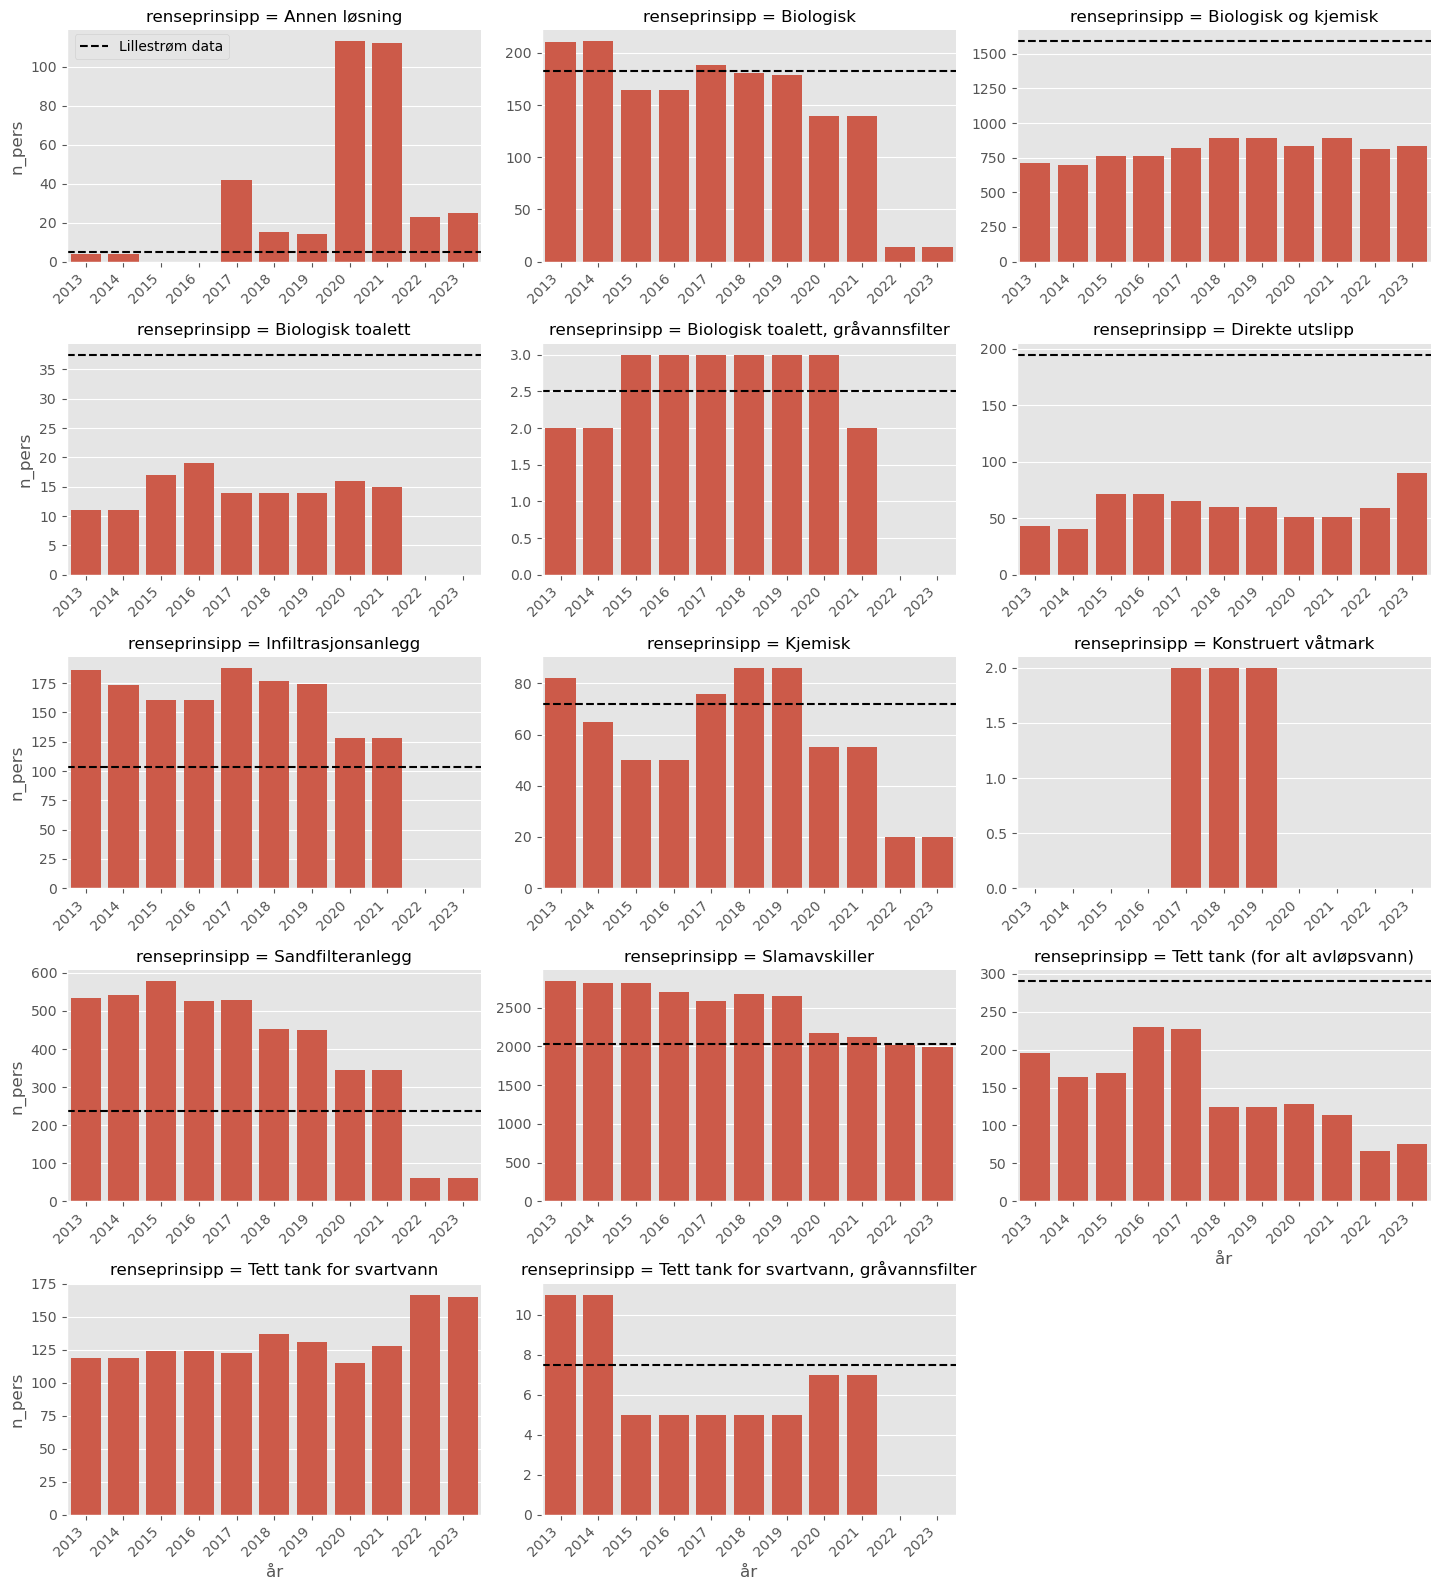

In [20]:
# Plot
g = sb.catplot(
    data=ssb_df,
    x="år",
    y="n_pers",
    col="renseprinsipp",
    col_wrap=3,
    kind="bar",
    sharex=False,
    sharey=False,
    height=3.2,
    aspect=1.5,
)

for ax, renseprinsipp in zip(g.axes.flat, g.col_names):
    row = lil_df.loc[lil_df["renseprinsipp"] == renseprinsipp].squeeze()

    if not row.empty:
        fills = ["Lillestrøm data"]
        colors = ["black"]
        for fill, color in zip(fills, colors):
            ax.axhline(
                y=row[fill],
                color=color,
                linestyle="--",
                linewidth=1.5,
                label=fill,
            )

for ax in g.axes.flat:
    ax.set_xticks(
        ax.get_xticks(),
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
    )

handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.fig.legend(
    handles,
    labels,
    loc="upper left",
    bbox_to_anchor=(0.05, 0.98),
)

plt.tight_layout()

plt.savefig("../plots/spredt_ssb_vs_lillestrom.png", dpi=200, bbox_inches="tight")